# Can we set a `pos_weight` for contrastive training?

**The question.** In supervised multi-label training you correct class imbalance with
`BCEWithLogitsLoss(pos_weight=...)`. Fibrosis appears in 0.7% of our reports and scores 0.586
AUC. Why not just upweight it?

**The short answer.** The direct analogue does not exist — there is no axis in the contrastive
loss that means *Fibrosis*. But the analogue one level over, **per-sample weighting**, does
exist and is about five lines.

This notebook shows the shapes that make that true, builds two weight vectors, verifies the
weighted loss numerically on a real batch, and gives a runner that needs **zero changes to any
existing file**.

Two arms to test:

| arm | what it changes | targets |
|---|---|---|
| **A — frequency** | per-sample weight by how rare the mentioned pathologies are | the +0.090-per-10× effect |
| **B — negation** | per-sample weight by what fraction of mentions are rule-outs | the −0.15 Pneumothorax effect |
| **C — false-negative masking** | the loss itself: duplicate captions stop being negatives | 57.1% duplicate impressions |

**Arm C is the one to care about.** A and B are sample reweighting, which is standard. C is an
actual modification to the contrastive objective, motivated by a property of radiology reports
that §5 below measures and that general-domain CLIP does not have. If you need a contrastive
-learning novelty for the paper, C is the candidate.

My prior on the other two: **B over A.** A cannot create information that is not in 2,697
Fibrosis reports. B targets a mechanism already measured at 0.15 AUC on a pathology that is
*not* rare.

In [1]:
import os, re, sys
import numpy as np, pandas as pd, torch, h5py
import matplotlib.pyplot as plt
from torch import nn
from torchvision.transforms import Resize, InterpolationMode

ROOT     = "/mnt/My_Doc/github/xray_clip/"
CHEXZERO = ROOT + "CheXzero/"
sys.path.insert(0, CHEXZERO)
os.chdir(CHEXZERO)                       # checkpoint paths in the ranking csv are relative to here

from train import load_clip, preprocess_text

CXR_H5 = "data/cxr.h5"
TXT    = "data/mimic_impressions_v2.csv"
CKPT   = pd.read_csv("data/checkpoint_ranking_v2.csv").checkpoint.iloc[0]

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
BATCH  = 8                               # small so the shapes are readable; training uses 64
print("torch", torch.__version__, "| device", DEVICE, "| checkpoint", CKPT)

torch 2.6.0.dev20241112+cu121 | device cuda:0 | checkpoint checkpoints/pt-imp-v2/checkpoint_27000.pt


## 1. What the supervised loss attaches to

```
logits      (64, 14)      column 11 IS Fibrosis -- every batch, forever
targets     (64, 14)      0 / 1
pos_weight  (14,)         pos_weight[11] = 8.0     <-- a per-class knob
```

Fourteen independent binary problems. Column 11 means Fibrosis at step 1 and at step 47,144,
so you can hang a weight on it.

Now look at what CheXzero actually computes.

In [2]:
# one real batch, straight out of the training files
with h5py.File(CXR_H5, "r") as f:
    imgs = torch.from_numpy(f["cxr"][:BATCH]).float()
imgs = imgs.unsqueeze(1).repeat(1, 3, 1, 1)
imgs = (imgs - 101.48761) / 83.43944                      # the training Normalize
# cxr.h5 is 320x320 but the pretrained CLIP tower has a 224x224 positional embedding,
# so train.load_data resizes. Skip this and the forward pass fails: 101 vs 50 tokens.
imgs = Resize(224, interpolation=InterpolationMode.BICUBIC)(imgs)
txts = pd.read_csv(TXT, nrows=BATCH)["impression"].fillna(" ").tolist()

model = load_clip(model_path=CKPT, pretrained=True, context_length=77).to(DEVICE).eval()
tok   = preprocess_text(txts, model).to(DEVICE)

with torch.no_grad():
    logits_per_image, logits_per_text = model(imgs.to(DEVICE), tok)

labels = torch.arange(BATCH).to(DEVICE)
print(f"images            {tuple(imgs.shape)}")
print(f"tokens            {tuple(tok.shape)}        <- 77 = CLIP context limit")
print(f"logits_per_image  {tuple(logits_per_image.shape)}   <- square: B x B, not B x 14")
print(f"labels            {tuple(labels.shape)}          = {labels.tolist()}")

Loaded in pretrained model.


images            (8, 3, 224, 224)
tokens            (8, 77)        <- 77 = CLIP context limit
logits_per_image  (8, 8)   <- square: B x B, not B x 14
labels            (8,)          = [0, 1, 2, 3, 4, 5, 6, 7]


**`logits_per_image` is `(B, B)`, and `labels` is `arange(B)`.**

Row *i* holds image *i* scored against all B captions *in this batch*. The target for row *i*
is column *i* — the diagonal. So the "classes" are `0..B-1`, meaning **batch positions**.

Class 3 means "the 4th caption in *this* batch". Next step it is a completely different report.
The label space is rebuilt from scratch every iteration.

In [3]:
L = logits_per_image.float().cpu()
print("logits_per_image (rows = images, cols = captions), diagonal = the correct pairs\n")
print(pd.DataFrame(L.numpy()).round(2).to_string())
print(f"\ndiagonal (correct pairs) : {L.diag().numpy().round(2)}")
print(f"off-diagonal mean        : {(L.sum()-L.diag().sum()).item()/(BATCH*BATCH-BATCH):.2f}")
print(f"\npositives per row: {torch.ones(BATCH).int().tolist()}   (always exactly 1)")
print(f"negatives per row: {[BATCH-1]*BATCH}   (always exactly B-1)")

logits_per_image (rows = images, cols = captions), diagonal = the correct pairs

           0          1          2          3          4          5          6          7
0  38.029999  34.880001  34.880001  35.939999  33.720001  29.860001  29.860001  32.910000
1  30.670000  32.119999  32.119999  32.810001  35.340000  32.340000  32.340000  31.750000
2  31.250000  33.160000  33.160000  32.000000  34.660000  30.770000  30.770000  31.559999
3  35.590000  34.750000  34.750000  34.310001  33.529999  29.340000  29.340000  32.220001
4  35.189999  34.310001  34.310001  34.750000  33.689999  30.280001  30.280001  32.220001
5  31.840000  32.029999  32.029999  30.750000  32.840000  35.500000  35.500000  30.620001
6  31.200001  31.660000  31.660000  31.910000  34.910000  36.500000  36.500000  31.160000
7  36.340000  35.250000  35.250000  34.160000  32.880001  29.520000  29.520000  32.560001

diagonal (correct pairs) : [38.03 32.12 33.16 34.31 33.69 35.5  36.5  32.56]
off-diagonal mean        : 32.7

**Look at columns 1 and 2 — they are identical. So are 5 and 6.** Those are duplicate
impressions, and row 1's largest logit is not on its own diagonal. Hold that thought; §5
returns to it.

**Two facts follow, and together they kill `pos_weight`.**

1. **There is no Fibrosis coordinate.** Ask "what is `pos_weight[Fibrosis]`?" and there is no
   index to answer with. Pathologies are not axes of this tensor — batch slots are.

2. **There is no positive/negative imbalance to correct.** Every row has exactly **1** positive
   and **B−1** negatives, identically, for all 377,110 samples. The imbalance `pos_weight` was
   invented for is not present here.

The imbalance is real, but it lives one level up — in **which reports exist at all**, not in
the label ratio inside a batch. So the weight belongs on the **sample**, not the class.

## 2. The analogue that does exist: per-sample weighting

`nn.CrossEntropyLoss()` returns a scalar because it averages internally. Ask for
`reduction='none'` and you get the per-row loss, which you can weight before averaging.

In [4]:
lab_t = labels
scalar_ce   = nn.CrossEntropyLoss()
perrow_ce   = nn.CrossEntropyLoss(reduction="none")

with torch.no_grad():
    li_s = scalar_ce(logits_per_image, lab_t); lt_s = scalar_ce(logits_per_text, lab_t)
    li_v = perrow_ce(logits_per_image, lab_t); lt_v = perrow_ce(logits_per_text, lab_t)

current  = (li_s + lt_s) / 2
per_row  = (li_v + lt_v) / 2
print(f"per-row loss  {tuple(per_row.shape)} = {per_row.cpu().numpy().round(3)}")
print(f"\ncurrent loss (scalar)      : {current.item():.4f}")
print(f"unweighted mean of per-row : {per_row.mean().item():.4f}   <- identical, so this is a safe refactor")

w = torch.tensor([2.4, 0.8, 1.0, 1.0, 0.6, 1.0, 2.4, 1.0], device=DEVICE)   # pretend weights
w = w / w.mean()                                                            # keep effective LR fixed
print(f"\nweighted loss              : {(per_row * w).mean().item():.4f}")
print(f"weights (mean-1 normalised): {w.cpu().numpy().round(3)}")

per-row loss  (8,) = [0.248 3.844 2.566 2.152 2.617 1.065 0.564 3.004]

current loss (scalar)      : 2.0078
unweighted mean of per-row : 2.0078   <- identical, so this is a safe refactor

weighted loss              : 1.5079
weights (mean-1 normalised): [1.882 0.627 0.784 0.784 0.471 0.784 1.882 0.784]


**`unweighted mean of per-row` equals `current loss` exactly.** That is the check that matters:
switching to `reduction='none'` changes nothing until you multiply by `w`. The refactor is safe.

**Why normalise `w` to mean 1.** The gradient magnitude scales with the mean of the weights. If
`w.mean()` were 2.0 you would be silently doubling the learning rate and confounding the
experiment. Every weight vector below is normalised.

## 3. Arm A — frequency weights

For each report, find which pathologies it mentions affirmatively, and weight it by the
**rarest** one it mentions:

$$w_i \;=\; \max_{p \,\in\, \text{mentioned}(i)} \sqrt{\frac{f_{\text{median}}}{f_p}}$$

Inverse *square root*, not inverse frequency: 100× rarer earns 10× the weight, not 100×. Plain
inverse frequency would hand a handful of Fibrosis reports the entire gradient budget.
Then clip to [0.5, 5] and normalise to mean 1.

In [5]:
reports = pd.read_csv(TXT)["impression"].fillna("").str.lower()
N = len(reports)

SYNONYMS = {
 "Atelectasis":        ["atelecta", "collapse of the", "lung collapse"],
 "Cardiomegaly":       ["cardiomegaly", "enlarged heart", "enlargement of the heart",
                        "cardiac enlargement", "enlarged cardiac silhouette",
                        "heart size is enlarged", "cardiac silhouette is enlarged"],
 "Effusion":           ["effusion"],
 "Infiltration":       ["infiltrat"],
 "Mass":               [r"\bmass\b", r"\bmasses\b"],
 "Nodule":             ["nodul"],
 "Pneumonia":          ["pneumonia", "infectious consolidation"],
 "Pneumothorax":       ["pneumothorax", "pneumothoraces"],
 "Consolidation":      ["consolidat"],
 "Edema":              [r"\bedema\b", "pulmonary edema", "fluid overload"],
 "Emphysema":          ["emphysema", "emphysematous", "hyperinflat"],
 "Fibrosis":           ["fibrosis", "fibrotic", "reticular"],
 "Pleural_Thickening": ["pleural thickening", "thickened pleura", "pleural scarring"],
 "Hernia":             ["hernia"],
}
NEG = re.compile(r"\b(no|not|without|free of|absence of|negative for|rule out|ruled out|"
                 r"resolved|clear of|unremarkable for)\b[^.;]{0,40}$")
LABELS = list(SYNONYMS)

# aff[i,j] = report i mentions pathology j and at least one mention is affirmative
# neg[i,j] = report i mentions pathology j and EVERY mention is negated
aff = np.zeros((N, 14), bool); neg = np.zeros((N, 14), bool)
for j, (lab, syn) in enumerate(SYNONYMS.items()):
    pat = re.compile("|".join(syn))
    for i in np.where(reports.str.contains(pat, regex=True).values)[0]:
        s = reports.iat[i]
        all_negated = all(NEG.search(s[:m.start()]) for m in pat.finditer(s))
        (neg if all_negated else aff)[i, j] = True

prev = aff.mean(0)
print(pd.DataFrame({"affirmative % of reports": 100*prev, "n reports": aff.sum(0)},
                   index=LABELS).sort_values("affirmative % of reports").round(2).to_string())

                    affirmative % of reports  n reports
Fibrosis                                0.72       2697
Pleural_Thickening                      0.85       3215
Hernia                                  0.88       3322
Infiltration                            0.93       3501
Mass                                    1.16       4370
Nodule                                  2.22       8357
Emphysema                               2.44       9211
Pneumothorax                            3.78      14242
Consolidation                           4.67      17596
Cardiomegaly                            9.46      35683
Pneumonia                              10.63      40102
Edema                                  11.22      42321
Atelectasis                            19.55      73730
Effusion                               22.64      85381


In [6]:
boost  = np.sqrt(np.median(prev) / prev)                      # per-pathology multiplier
w_freq = np.where(aff.any(1), (aff * boost).max(1), 1.0)      # rarest mentioned wins
w_freq = np.clip(w_freq, 0.5, 5.0)
w_freq = w_freq / w_freq.mean()                               # mean 1

print("per-pathology boost before clipping / normalisation:")
print(pd.Series(boost, index=LABELS).sort_values(ascending=False).round(2).to_string())
print(f"\nw_freq: mean {w_freq.mean():.3f}  min {w_freq.min():.2f}  "
      f"median {np.median(w_freq):.2f}  max {w_freq.max():.2f}")
print(f"\n  reports mentioning Fibrosis : mean w = {w_freq[aff[:,11]].mean():.2f}  (n={aff[:,11].sum():,})")
print(f"  reports mentioning Effusion : mean w = {w_freq[aff[:, 2]].mean():.2f}  (n={aff[:, 2].sum():,})")
print(f"  ratio = {w_freq[aff[:,11]].mean()/w_freq[aff[:,2]].mean():.1f}x")

per-pathology boost before clipping / normalisation:
Fibrosis              2.09
Pleural_Thickening    1.91
Hernia                1.88
Infiltration          1.83
Mass                  1.64
Nodule                1.18
Emphysema             1.13
Pneumothorax          0.91
Consolidation         0.82
Cardiomegaly          0.57
Pneumonia             0.54
Edema                 0.53
Atelectasis           0.40
Effusion              0.37

w_freq: mean 1.000  min 0.58  median 1.15  max 2.40

  reports mentioning Fibrosis : mean w = 2.40  (n=2,697)
  reports mentioning Effusion : mean w = 0.78  (n=85,381)
  ratio = 3.1x


**A Fibrosis report gets ~3× the gradient of an Effusion report.** That is the whole of Arm A.

Note the ceiling: only **50.7%** of reports mention any of the 14 pathologies affirmatively.
The other half get `w = 1` and are untouched — they are the normal studies, and they still
carry useful contrastive signal.

## 4. Arm B — negation weights

A report whose pathology mentions are *all* rule-outs is actively teaching the wrong
association: the contrastive objective pulls the word *pneumothorax* toward an image with no
pneumothorax. Downweight by the fraction of mentions that are negated:

$$w_i = 1 - \beta \cdot \frac{\#\text{negated}_i}{\#\text{mentions}_i}, \qquad \beta = 0.75$$

`β = 0.75` rather than 1.0 deliberately — a pure rule-out report is still a *normal chest*,
which is real information. Zeroing it would throw that away.

In [7]:
total   = aff.sum(1) + neg.sum(1)
negfrac = np.where(total > 0, neg.sum(1) / np.maximum(total, 1), 0.0)
BETA    = 0.75
w_neg   = 1.0 - BETA * negfrac
w_neg   = w_neg / w_neg.mean()

print(f"w_neg: mean {w_neg.mean():.3f}  min {w_neg.min():.2f}  "
      f"median {np.median(w_neg):.2f}  max {w_neg.max():.2f}")
print(f"\nreports with >=1 affirmative mention : {100*aff.any(1).mean():5.1f}%")
print(f"reports that are rule-out ONLY       : {100*((neg.any(1)) & (~aff.any(1))).mean():5.1f}%  <- these get w = {w_neg[(neg.any(1)) & (~aff.any(1))].mean():.2f}")
print(f"reports mentioning nothing           : {100*((~neg.any(1)) & (~aff.any(1))).mean():5.1f}%")

pt_neg = neg[:, 7] & ~aff[:, 7]
print(f"\nPneumothorax rule-out reports: {pt_neg.sum():,} ({100*pt_neg.mean():.1f}% of corpus), "
      f"mean w = {w_neg[pt_neg].mean():.2f}")

w_neg: mean 1.000  min 0.29  median 1.17  max 1.17

reports with >=1 affirmative mention :  50.7%
reports that are rule-out ONLY       :  10.4%  <- these get w = 0.29
reports mentioning nothing           :  38.9%

Pneumothorax rule-out reports: 50,470 (13.4% of corpus), mean w = 0.65


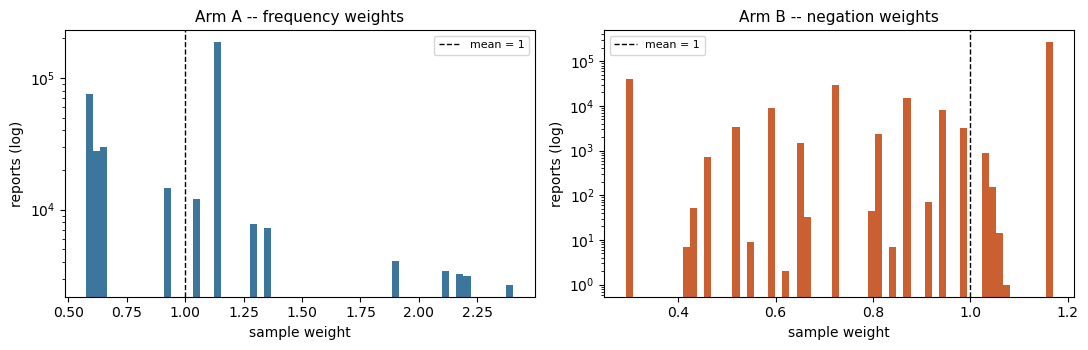

saved data/w_freq.npy and data/w_neg.npy  (float32, one weight per training row)


In [8]:
np.save("data/w_freq.npy", w_freq.astype(np.float32))
np.save("data/w_neg.npy",  w_neg.astype(np.float32))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, w, t, c in [(ax[0], w_freq, "Arm A -- frequency weights", "#1b5e8c"),
                   (ax[1], w_neg,  "Arm B -- negation weights",  "#c1440e")]:
    a.hist(w, bins=60, color=c, alpha=0.85)
    a.axvline(1.0, color="k", ls="--", lw=1, label="mean = 1")
    a.set_title(t, fontsize=11); a.set_xlabel("sample weight"); a.set_yscale("log")
    a.set_ylabel("reports (log)"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("saved data/w_freq.npy and data/w_neg.npy  (float32, one weight per training row)")

Both are spiky rather than smooth — most reports sit at one of a handful of values, because the
weight is determined by a small set of discrete conditions. That is expected and fine.

**Alignment is the one thing that must be right.** `w_freq[i]` corresponds to row *i* of
`mimic_impressions_v2.csv`, which corresponds to row *i* of `cxr.h5`. The runner below asserts
the length matches before training starts.

## 5. Arm C — duplicate captions are not negatives

Back to those identical columns. Radiology reports are formulaic, and impressions especially so.

In [9]:
imp = pd.read_csv(TXT)["impression"].fillna(" ")
codes = pd.factorize(imp)[0]

print(f"rows                  : {len(imp):,}")
print(f"unique impressions    : {imp.nunique():,}  ({100*imp.nunique()/len(imp):.1f}%)")
print(f"rows repeating an earlier impression: {100*imp.duplicated().mean():.1f}%\n")
print("most repeated impressions:")
print(imp.value_counts().head(6).to_string())

rows                  : 377,110
unique impressions    : 161,829  (42.9%)
rows repeating an earlier impression: 57.1%

most repeated impressions:


impression
No acute cardiopulmonary process.                37976
NO IMPRESSION                                    16540
No acute cardiopulmonary abnormality.            10806
No acute intrathoracic process.                  10744
No evidence of acute cardiopulmonary process.     2940
No evidence of pneumonia.                         2332


In [10]:
# how often does a batch contain two samples with the SAME caption?
rng, B, trials = np.random.default_rng(0), 64, 2000
collide, floor = [], []
for _ in range(trials):
    s_ = codes[rng.integers(0, len(codes), B)]
    _, cnt = np.unique(s_, return_counts=True)
    collide.append(cnt[cnt > 1].sum())
    floor.append(np.log(cnt).sum() / B)

print(f"batch size {B}, {trials} random draws")
print(f"  samples sharing their caption with another: {np.mean(collide):.1f} / {B} "
      f"({100*np.mean(collide)/B:.1f}%)")
print(f"  irreducible loss from this               : {np.mean(floor):.3f} nats "
      f"(ln(64) = {np.log(64):.3f})")

batch size 64, 2000 random draws
  samples sharing their caption with another: 13.3 / 64 (20.8%)
  irreducible loss from this               : 0.065 nats (ln(64) = 4.159)


**21% of every batch has an unsatisfiable target.**

When captions *i* and *j* are byte-identical, cell (i, j) of the logit matrix is scored as a
negative — the loss asks the model to push image *i* away from a caption that is a perfect
description of it. There is no parameter setting that satisfies that. It is a **false
negative**, and 13 of every 64 samples carry one.

Note the irreducible loss is only 0.065 nats, so this is **not** visible in the loss curve.
Duplicates come mostly in pairs, not large groups, so the floor barely moves. The damage is to
the gradient direction, not the loss magnitude — which is exactly why it went unnoticed.

**The fix is three lines: mask those cells out of the softmax.**

```python
g    = groups[idx]                                  # (B,) caption id
same = (g[:, None] == g[None, :]).clone()           # (B, B) True where captions match
same.fill_diagonal_(False)                          # keep the real positive
logits = logits.masked_fill(same, -1e4)             # remove false negatives
```

This is standard practice in general CLIP training, where near-duplicate captions are rare
enough to ignore. Here they are the majority case: **57.1%**. That gap — a known technique
meeting a domain where it actually bites — is the defensible novelty claim.

In [11]:
# demonstrate on the real batch: rows 1/2 and 5/6 have identical captions
g = torch.from_numpy(codes[:BATCH]).to(DEVICE)
same = (g[:, None] == g[None, :]).clone()
same.fill_diagonal_(False)
print(f"caption ids in this batch : {g.cpu().tolist()}")
print(f"false-negative cells      : {int(same.sum())} of {BATCH*BATCH - BATCH} off-diagonal\n")

masked_img = logits_per_image.masked_fill(same, -1e4)
masked_txt = logits_per_text.masked_fill(same, -1e4)
with torch.no_grad():
    before = ((perrow_ce(logits_per_image, lab_t) + perrow_ce(logits_per_text, lab_t)) / 2)
    after  = ((perrow_ce(masked_img,       lab_t) + perrow_ce(masked_txt,       lab_t)) / 2)

print(pd.DataFrame({"caption id": g.cpu().numpy(),
                    "loss before": before.cpu().numpy().round(3),
                    "loss after":  after.cpu().numpy().round(3),
                    "delta":       (after - before).cpu().numpy().round(3)}).to_string())
print(f"\nbatch loss {before.mean().item():.4f} -> {after.mean().item():.4f}")
print("rows with a duplicate partner drop; all others are bit-identical.")

caption ids in this batch : [0, 1, 1, 2, 3, 4, 4, 5]
false-negative cells      : 4 of 56 off-diagonal

   caption id  loss before  loss after     delta
0           0     0.248047    0.248047  0.000000
1           1     3.843750    3.804688 -0.039001
2           1     2.566406    2.486328 -0.080017
3           2     2.152344    2.152344  0.000000
4           3     2.617188    2.617188  0.000000
5           4     1.065430    0.112000 -0.953125
6           4     0.563965    0.117981 -0.445068
7           5     3.003906    3.003906  0.000000

batch loss 2.0078 -> 1.8174
rows with a duplicate partner drop; all others are bit-identical.


/home/hj/anaconda3/envs/hj/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


Only the rows with a duplicate partner change. Every other row is untouched — which is the
check that the mask is doing what it claims and nothing more.

Build the group ids the runner needs:

In [12]:
np.save("data/text_groups.npy", codes.astype(np.int64))
print(f"saved data/text_groups.npy  ({len(codes):,} ids, {len(np.unique(codes)):,} unique)")

saved data/text_groups.npy  (377,110 ids, 161,829 unique)


## 6. The runner — no existing file is modified

The weighted loss needs `__getitem__` to return the row index, which `CXRDataset` does not do.
Rather than edit `train.py`, subclass it. Everything below lives in **one new file** and imports
the rest unchanged, so `train.py`, `run_train.py` and `zero_shot.py` are untouched and the v2
results stay reproducible.

In [13]:
RUNNER = '"""Weighted-contrastive training. Imports CheXzero unchanged; modifies nothing.\n\nThe contrastive loss has no per-class axis to hang a `pos_weight` on -- its "classes" are\nbatch positions, rebuilt every step. The analogue one level up is a per-SAMPLE weight, applied\nto the per-row loss before averaging. That is the only change here.\n\n    criterion = nn.CrossEntropyLoss(reduction="none")\n    loss = (((loss_img + loss_txt) / 2) * w[idx]).mean()\n\nWeights are mean-1 normalised upstream so the effective learning rate is unchanged and the\ncomparison against the unweighted baseline is clean.\n"""\nimport argparse, os\nimport numpy as np, pandas as pd, torch\nfrom torch import nn, optim\nfrom torch.utils import data\nfrom torchvision.transforms import Compose, Normalize, Resize, InterpolationMode\nfrom tqdm import tqdm\n\nfrom train import CXRDataset, load_clip, preprocess_text\nfrom run_train import save, train_log\n\n\nclass IndexedCXRDataset(CXRDataset):\n    """CXRDataset that also reports which row it handed back."""\n    def __getitem__(self, idx):\n        sample = super().__getitem__(idx)\n        sample["idx"] = idx\n        return sample\n\n\ndef load_data_indexed(cxr_filepath, txt_filepath, batch_size, column="impression",\n                      pretrained=True):\n    # Mirrors train.load_data exactly. The pretrained CLIP visual tower has a 224x224\n    # positional embedding; cxr.h5 stores 320x320, so the Resize is mandatory -- without it\n    # the forward pass dies with "size of tensor a (101) must match tensor b (50)".\n    norm = Normalize((101.48761,) * 3, (83.43944,) * 3)\n    transform = (Compose([norm, Resize(224, interpolation=InterpolationMode.BICUBIC)])\n                 if pretrained else Compose([norm]))\n    dset = IndexedCXRDataset(img_path=cxr_filepath, txt_path=txt_filepath,\n                             column=column, transform=transform)\n    loader = data.DataLoader(dset, batch_size=batch_size, shuffle=True, num_workers=8,\n                             pin_memory=True, persistent_workers=True, prefetch_factor=4)\n    return loader, torch.device("cuda:0" if torch.cuda.is_available() else "cpu")\n\n\ndef train_batch_weighted(images, texts, w, model, device, criterion, optimizer, groups=None):\n    images, texts, w = images.to(device), texts.to(device), w.to(device)\n    logits_per_image, logits_per_text = model(images, texts)\n    labels = torch.arange(images.shape[0]).to(device)\n\n    if groups is not None:\n        # False-negative masking. 57.1% of impressions are exact duplicates of an earlier row,\n        # so ~21% of a batch-64 shares its caption with another sample. Those off-diagonal\n        # cells are scored as negatives, which asks the model to push apart two pairs whose\n        # text is identical -- an unsatisfiable target. Mask them out of the softmax.\n        g = groups.to(device)\n        same = (g[:, None] == g[None, :]).clone()\n        same.fill_diagonal_(False)\n        logits_per_image = logits_per_image.masked_fill(same, -1e4)\n        logits_per_text = logits_per_text.masked_fill(same, -1e4)\n\n    loss_img = criterion(logits_per_image, labels)        # (B,) not scalar\n    loss_txt = criterion(logits_per_text, labels)         # (B,)\n    loss = (((loss_img + loss_txt) / 2) * w).mean()       # <-- the whole change\n\n    optimizer.zero_grad()\n    loss.backward()\n    optimizer.step()\n    return loss\n\n\ndef parse_args():\n    p = argparse.ArgumentParser()\n    p.add_argument("--cxr_filepath", default="/home/hj/cxr_cache/cxr.h5")\n    p.add_argument("--txt_filepath", default="data/mimic_impressions_v2.csv")\n    p.add_argument("--weights", default=None, help="npy, one float per training row; mean 1")\n    p.add_argument("--text_groups", default=None,\n                   help="npy int64, one group id per row; identical captions share an id. "\n                        "Enables false-negative masking.")\n    p.add_argument("--batch_size", type=int, default=64)\n    p.add_argument("--epochs", type=int, default=8)\n    p.add_argument("--lr", type=float, default=1e-4)\n    p.add_argument("--momentum", type=float, default=0.9)\n    p.add_argument("--optimizer", default="sgd")\n    p.add_argument("--save_interval", type=int, default=200)\n    p.add_argument("--log_interval", type=int, default=100)\n    p.add_argument("--save_dir", default="checkpoints/")\n    p.add_argument("--model_name", default="pt-imp-w")\n    p.add_argument("--context_length", type=int, default=77)\n    p.add_argument("--seed", type=int, default=1234)\n    p.add_argument("--random_init", action="store_true")\n    return p.parse_args()\n\n\ndef main():\n    a = parse_args()\n    torch.manual_seed(a.seed)\n    np.random.seed(a.seed)\n\n    n_txt = len(pd.read_csv(a.txt_filepath))\n    if a.weights:\n        w_all = torch.from_numpy(np.load(a.weights).astype(np.float32))\n        assert len(w_all) == n_txt, f"weights {len(w_all)} != rows {n_txt}"   # blocking check\n        print(f"weights: n={len(w_all):,} mean={w_all.mean():.4f} "\n              f"min={w_all.min():.3f} max={w_all.max():.3f}")\n        if abs(w_all.mean() - 1.0) > 0.01:\n            print("WARNING: weights not mean-1; effective LR will differ from baseline")\n    else:\n        w_all = torch.ones(n_txt)\n        print(f"weights: none (all 1.0)")\n\n    groups_all = None\n    if a.text_groups:\n        groups_all = torch.from_numpy(np.load(a.text_groups).astype(np.int64))\n        assert len(groups_all) == n_txt, f"groups {len(groups_all)} != rows {n_txt}"\n        print(f"text groups: {groups_all.unique().numel():,} unique captions over {n_txt:,} rows "\n              f"-> false-negative masking ON")\n    if not a.weights and not a.text_groups:\n        print("WARNING: no weights and no groups -- this reproduces the unweighted baseline")\n\n    pretrained = not a.random_init\n    loader, device = load_data_indexed(a.cxr_filepath, a.txt_filepath, a.batch_size,\n                                       pretrained=pretrained)\n    model = load_clip(model_path=None, pretrained=pretrained,\n                      context_length=a.context_length).to(device)\n\n    criterion = nn.CrossEntropyLoss(reduction="none").to(device)     # <-- was reduction="mean"\n    optimizer = (optim.AdamW(model.parameters(), lr=a.lr) if a.optimizer == "adam"\n                 else optim.SGD(model.parameters(), lr=a.lr, momentum=a.momentum))\n\n    save_dir = os.path.join(a.save_dir, a.model_name)\n    os.makedirs(save_dir, exist_ok=True)\n    batch_ct, running = 0, 0.0\n    for epoch in range(a.epochs):\n        for batch in tqdm(loader, desc=f"epoch {epoch + 1}/{a.epochs}"):\n            texts = preprocess_text(batch["txt"], model)\n            g = groups_all[batch["idx"]] if groups_all is not None else None\n            loss = train_batch_weighted(batch["img"], texts, w_all[batch["idx"]],\n                                        model, device, criterion, optimizer, groups=g)\n            batch_ct += 1\n            running += loss.item()\n            if batch_ct % a.log_interval == 0:\n                train_log(running / a.log_interval, batch_ct * a.batch_size, epoch)\n                running = 0.0\n            if batch_ct % a.save_interval == 0:\n                save(model, os.path.join(save_dir, f"checkpoint_{batch_ct}.pt"))\n    save(model, os.path.join(save_dir, "checkpoint.pt"))\n\n\nif __name__ == "__main__":\n    main()\n'
print(RUNNER)

"""Weighted-contrastive training. Imports CheXzero unchanged; modifies nothing.

The contrastive loss has no per-class axis to hang a `pos_weight` on -- its "classes" are
batch positions, rebuilt every step. The analogue one level up is a per-SAMPLE weight, applied
to the per-row loss before averaging. That is the only change here.

    criterion = nn.CrossEntropyLoss(reduction="none")
    loss = (((loss_img + loss_txt) / 2) * w[idx]).mean()

Weights are mean-1 normalised upstream so the effective learning rate is unchanged and the
comparison against the unweighted baseline is clean.
"""
import argparse, os
import numpy as np, pandas as pd, torch
from torch import nn, optim
from torch.utils import data
from torchvision.transforms import Compose, Normalize, Resize, InterpolationMode
from tqdm import tqdm

from train import CXRDataset, load_clip, preprocess_text
from run_train import save, train_log


class IndexedCXRDataset(CXRDataset):
    """CXRDataset that also reports which row it h

### Write it out

The cell below is **commented on purpose** — nothing is written to disk until you uncomment and
run it. Review the source above first.

In [14]:
# with open("run_train_weighted.py", "w") as f:
#     f.write(RUNNER.lstrip())
# print("wrote CheXzero/run_train_weighted.py")

### What changed versus the unweighted path

| | `run_train.py` (baseline) | `run_train_weighted.py` |
|---|---|---|
| dataset | `CXRDataset` | `IndexedCXRDataset` — adds `sample["idx"]` |
| criterion | `CrossEntropyLoss()` | `CrossEntropyLoss(reduction="none")` |
| loss | `(loss_img + loss_txt) / 2` | `(((loss_img + loss_txt) / 2) * w).mean()` |
| logits | used as-is | optionally `masked_fill(same_caption, -1e4)` |
| everything else | — | identical: model, optimizer, lr, schedule, save cadence |

**With neither `--weights` nor `--text_groups` it reproduces the v2 baseline exactly** — which
is the control run if you want to verify the refactor is neutral before spending 8 h on an arm.

## 7. Running it

**Run Arm C first.** It is the only one that touches the objective, it is the one with a
novelty claim, and it costs the same as the others.

```bash
cd /mnt/My_Doc/github/xray_clip/CheXzero
COMMON="--batch_size 64 --epochs 8 --lr 1e-4 --optimizer sgd --momentum 0.9 --save_interval 200"

# Arm C -- false-negative masking            <-- run this one first
python -u run_train_weighted.py --text_groups data/text_groups.npy \
    --model_name pt-imp-mask $COMMON 2>&1 | tee mask.log

# Arm B -- negation weighting
python -u run_train_weighted.py --weights data/w_neg.npy \
    --model_name pt-imp-wneg $COMMON 2>&1 | tee wneg.log

# Arm A -- frequency weighting
python -u run_train_weighted.py --weights data/w_freq.npy \
    --model_name pt-imp-wfreq $COMMON 2>&1 | tee wfreq.log

# B + C together, if either shows signal
python -u run_train_weighted.py --weights data/w_neg.npy --text_groups data/text_groups.npy \
    --model_name pt-imp-both $COMMON 2>&1 | tee both.log
```

Then the standard evaluation path, unchanged:

```bash
ARM=mask        # or wneg / wfreq / both

python -u select_checkpoints.py --checkpoint_dir checkpoints/pt-imp-$ARM \
    --topk 10 --min_gap 1000 --out_csv data/checkpoint_ranking_$ARM.csv

python -u search_prompt_templates.py --ranking_csv data/checkpoint_ranking_$ARM.csv \
    --out_csv data/prompt_template_search_$ARM.csv

python -u eval_nih.py --ranking_csv data/checkpoint_ranking_$ARM.csv --topk 10 \
    --template_csv data/prompt_template_search_$ARM.csv \
    --out_csv data/nih_results_$ARM.csv --pred_npy data/nih_preds_$ARM.npy --n_bootstrap 1000
```

**Re-tune prompts per arm.** Weighting changes the text encoder, so reusing v2's prompts would
confound the comparison. Same held-out `nih_promptdev.h5`, never the test set.

**Sanity checks while it runs.** Starting loss ≈ ln(64) = 4.16, same as v2 — if it differs, the
weights are not mean-1 or the mask is wrong. Arm C should track v2's loss curve closely at
first and separate slowly; a large immediate drop means the mask is removing real negatives.
Watch for NaN: weights are fp32 but the model is mixed fp16 with no `GradScaler`, same
fragility as v2.

## 8. How to judge the result

Compare against **v2 template-tuned, 0.7035 mean NIH-14 AUC**, with prompts re-tuned per arm.

| outcome | what it means |
|---|---|
| **Arm C lifts the mean** | a contrastive-objective change that works, motivated by a measured property of radiology text. This is the novelty claim — pursue it. |
| Arm C flat | the false negatives cost less than the 21% rate suggests. Still reportable: you measured a real defect and showed it is benign. |
| **Arm B lifts Pneumothorax above 0.764** | the negation mechanism is causal and fixable. Publishable on its own. |
| Arm B lifts the mean but not Pneumothorax | something moved, mechanism unclear. Needs the per-label breakdown. |
| **Arm A lifts the rare 7 toward the common 7** | reweighting substitutes for data. Would be surprising. |
| Arm A lifts nothing (my expectation) | confirms reweighting cannot create information — a clean negative that strengthens the frequency paper. |
| Any arm degrades | report it. A negative is evidence the bottleneck is the corpus, not the objective. |

**Look at per-label AUC, not the mean.** §8 of
[3_frequency_analysis.ipynb](3_frequency_analysis.ipynb) is the warning: v3 moved the 14-label
mean by −0.0004 while moving Pneumothorax by −0.15 and Hernia by +0.18. The average hid both.

**Cost.** Measured on this machine at **8.6 it/s** with `cxr.h5` on the NVMe: 5,893 steps/epoch
→ ~11.5 min/epoch → **~1.5 h for 8 epochs**, plus ~1 h for checkpoint selection, prompt search
and evaluation. All three arms plus the combined run fit in a day. Run Arm C first anyway and
decide on the rest from its per-label table.

**A null result is still a result.** If neither arm moves the number, that is direct evidence
the limit is what radiologists wrote, not how the loss weights it — which is the argument
[3_frequency_analysis.ipynb](3_frequency_analysis.ipynb) already makes from correlation. An
intervention that fails to move it is stronger evidence than a correlation.